In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from tqdm import tqdm

import sys
sys.path.append("../src")


from geodesiq import *

# Landau-Zener model (adiabatic evolution)

In [22]:
# ----- Define Hamiltonian -----
def ham(z, x):
    return np.array([[z, x],
                     [x, -z]])


hamiltonian = Hamiltonian(ham)

# ----- Set system and control parameters -----
alpha = 2
beta = 2
x = 1
z0 = -10
zf = -z0

hamiltonian.set_parameters(x=x)
hamiltonian.set_control(control_name='z', pulse_initial=z0, pulse_final=zf,
                        initial_state=0, alpha=alpha, beta=beta)

# ----- Solve for optimal pulse -----
hamiltonian.solve_problem(pulse_accuracy=int(1000))

In [23]:
hamiltonian.print_summary()

------------------ Hamiltonian Control Summary ------------------
Hamiltonian: ✅ set
Partial Hamiltonian: ❌ not set
Hamiltonian parameters: x: 1
Control name → z
Pulse initial → -10
Pulse final → 10
Initial state index → 0
Final state index → 0
(Alpha, Beta) → (2, 2)
(Diabatic Alpha, Diabatic Beta) → (❌ not set, ❌ not set)
Eigenproblem solved → ✅ yes
Metric computed → ✅ yes
ODE solved → ✅ yes
---------------------------------------------------------------


In [24]:
gate_fid = Dynamics(duration=50, hamiltonian=hamiltonian).average_gate_fidelity(target_gate=qt.sigmax())
print('Average gate fidelity (at t=tf): ', gate_fid[-1])

Average gate fidelity (at t=tf):  0.977891048276598


In [25]:
dynamics = Dynamics(duration=100, hamiltonian=hamiltonian)

fidelity = dynamics.state_fidelity(c_ops=[])
fidelity_noisy = dynamics.state_fidelity(c_ops=[qt.sigmaz()])
print(fidelity, fidelity_noisy)

0.9999996556418919 0.5000000001118995


In [26]:
def fidelity_vs_time(durations, hamiltonian, alpha=2, beta=2):

    hamiltonian.set_control(alpha=alpha, beta=beta)
    hamiltonian.solve_problem(pulse_accuracy=int(1000))

    fidelities = []
    for duration in tqdm(durations):
        dynamics = Dynamics(duration=duration, hamiltonian=hamiltonian)
        fidelities.append(dynamics.state_fidelity())

    return np.array(fidelities)

In [27]:
durations = np.linspace(0, 10, 200)
fidelities_geometric = fidelity_vs_time(durations, hamiltonian, alpha=2, beta=2)
fidelities_faquad = fidelity_vs_time(durations, hamiltonian, alpha=4, beta=2)

100%|██████████| 200/200 [00:07<00:00, 28.06it/s]


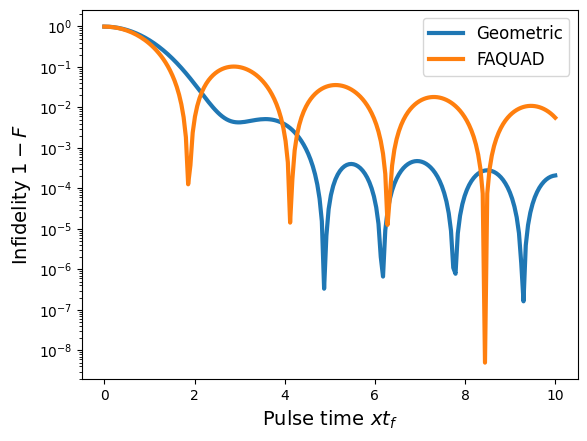

In [28]:
plt.plot(durations, 1-fidelities_geometric, label='Geometric', lw=3)
plt.plot(durations, 1-fidelities_faquad, label='FAQUAD', lw=3)
plt.yscale('log')
plt.ylabel('Infidelity $1-F$', fontsize=14)
plt.xlabel('Pulse time $x t_f$', fontsize=14)
plt.legend(fontsize=12)
plt.show()

# Double quantum dot model (adiabtic initialization)

In [5]:
def dqd_hamiltonian(eps, U, tc, Ez, dEz, dEx):
    ham = np.array([
        [U-eps, 0, -tc, tc, 0],
        [0, Ez, dEx, -dEx, 0],
        [-tc, dEx, dEz, 0, dEx],
        [tc, -dEx, 0, -dEz, -dEx],
        [0, 0, dEx, -dEx, -Ez]
    ])
    return ham


dqd_hamiltonian = Hamiltonian(dqd_hamiltonian)

# ----- Set system and control parameters -----
alpha = 2
beta = 2
U, tc, Ez, dEz, dEx = 10, 1, .9, .1, .01
eps0 = 15
epsf = 0

dqd_hamiltonian.set_parameters(U=U, tc=tc, Ez=Ez, dEz=dEz, dEx=dEx)
dqd_hamiltonian.set_control(control_name='eps', pulse_initial=eps0, pulse_final=epsf,
                        initial_state=0, alpha=alpha, beta=beta)

# ----- Solve for optimal pulse -----
dqd_hamiltonian.solve_problem(pulse_accuracy=int(1000))

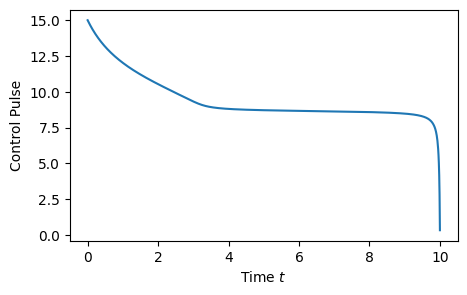

(<Figure size 500x300 with 1 Axes>,
 <Axes: xlabel='Time $t$', ylabel='Control Pulse'>)

In [6]:
dqd_hamiltonian.synthesize_pulse(duration=10, method='plot')

In [10]:
durations = np.linspace(0, 1000, 200)
fidelities_geometric = fidelity_vs_time(durations, dqd_hamiltonian, alpha=2, beta=2)
fidelities_faquad = fidelity_vs_time(durations, dqd_hamiltonian, alpha=4, beta=2)

100%|██████████| 200/200 [00:37<00:00,  5.36it/s]


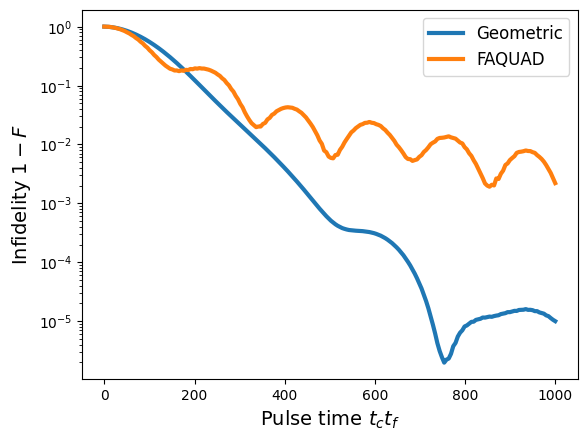

In [11]:
plt.plot(durations, 1-fidelities_geometric, label='Geometric', lw=3)
plt.plot(durations, 1-fidelities_faquad, label='FAQUAD', lw=3)
plt.yscale('log')
plt.ylabel('Infidelity $1-F$', fontsize=14)
plt.xlabel('Pulse time $t_c t_f$', fontsize=14)
plt.legend(fontsize=12)
plt.show()